# Fleet Dispatcher: Hourly Pickup Demand Forecasting

## Project objective

Build a practical demand forecasting workflow that helps a taxi fleet dispatcher decide **where vehicles should be positioned before demand arrives**. The model forecasts pickup counts by origin zone for the next 24-72 hours and converts those forecasts into ranked operational recommendations.



In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

# Locate the repository root when the notebook is opened from different working directories.
candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidates if (path / "data" / "processed").exists()),
    Path.cwd(),
)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_PATH = PROCESSED_DIR / "Urban_Flow_Analytics_Taxi_Clean_Enriched_12Month.parquet"
TOP_N = 10
FORECAST_HORIZON = 72
RANDOM_STATE = 42

assert SOURCE_PATH.exists(), f"Missing processed dataset: {SOURCE_PATH}"

source_columns = pd.read_parquet(SOURCE_PATH, engine="pyarrow").columns.tolist()
required_columns = {
    "pickup_timestamp",
    "origin_loc_id",
    "origin_borough",
    "origin_zone",
    "origin_service_zone",
}
missing_columns = required_columns.difference(source_columns)
assert not missing_columns, f"Missing required processed columns: {sorted(missing_columns)}"

print("Fleet Dispatcher setup complete")
print(f"Project root: {PROJECT_ROOT}")
print(f"Processed source rows available: {len(pd.read_parquet(SOURCE_PATH, columns=['origin_loc_id'], engine='pyarrow')):,}")
print(f"Required processed columns present: {sorted(required_columns)}")
print("Forecasting modal scope: hourly pickup demand by origin zone")


Fleet Dispatcher setup complete
Project root: c:\Users\kATANA GF66\My_Main\datathon\Datathon-2026-team-DataCraft
Processed source rows available: 45,956,110
Required processed columns present: ['origin_borough', 'origin_loc_id', 'origin_service_zone', 'origin_zone', 'pickup_timestamp']
Forecasting modal scope: hourly pickup demand by origin zone


## 1. Load the forecasting inputs

Only the timestamp and pickup-zone columns are loaded from the 45.9 million-row source. The hourly target is a row count: each cleaned trip contributes one pickup to its origin zone and pickup hour.

In [2]:
# Load only forecasting fields from the processed enriched Parquet.
taxi_events = pd.read_parquet(
    SOURCE_PATH,
    columns=[
        "pickup_timestamp",
        "origin_loc_id",
        "origin_borough",
        "origin_zone",
        "origin_service_zone",
    ],
    engine="pyarrow",
)
taxi_events["pickup_timestamp"] = pd.to_datetime(
    taxi_events["pickup_timestamp"], errors="coerce"
)
taxi_events["origin_loc_id"] = pd.to_numeric(
    taxi_events["origin_loc_id"], errors="coerce"
)
taxi_events = taxi_events.dropna(subset=["pickup_timestamp", "origin_loc_id"])
taxi_events["origin_loc_id"] = taxi_events["origin_loc_id"].astype("int16")
taxi_events["timestamp"] = taxi_events["pickup_timestamp"].dt.floor("h")

print("Processed taxi and zone fields loaded from one Parquet source")
print("Taxi event rows loaded:", f"{len(taxi_events):,}")
print("Observed period:", taxi_events["timestamp"].min(), "to", taxi_events["timestamp"].max())
print("Embedded zone columns:", [
    "origin_borough", "origin_zone", "origin_service_zone"
])
display(taxi_events.head())


Processed taxi and zone fields loaded from one Parquet source
Taxi event rows loaded: 45,956,110
Observed period: 2008-12-31 23:00:00 to 2026-04-01 00:00:00
Embedded zone columns: ['origin_borough', 'origin_zone', 'origin_service_zone']


,pickup_timestamp,origin_loc_id,origin_borough,origin_zone,origin_service_zone,timestamp
0,2025-04-01 00:47:06,138,Queens,LaGuardia Airport,Airports,2025-04-01
1,2025-04-01 00:27:35,138,Queens,LaGuardia Airport,Airports,2025-04-01
2,2025-04-01 00:24:07,132,Queens,JFK Airport,Airports,2025-04-01
3,2025-04-01 00:56:30,79,Manhattan,East Village,Yellow Zone,2025-04-01
4,2025-04-01 00:00:17,161,Manhattan,Midtown Center,Yellow Zone,2025-04-01


## 2. Confirm the forecasting coverage

The source contains timestamp outliers outside the documented April 2025–March 2026 collection window. They are excluded from this demand forecast so that the time index represents the actual 12-month operating period.

In [3]:
EXPECTED_START = pd.Timestamp("2025-04-01 00:00:00")
EXPECTED_END = pd.Timestamp("2026-04-01 00:00:00")

coverage_summary = (
    taxi_events.assign(month=taxi_events["timestamp"].dt.to_period("M"))
    .groupby("month", as_index=False)
    .size()
    .rename(columns={"size": "pickup_rows"})
)
display(coverage_summary)

out_of_window = ~taxi_events["timestamp"].between(
    EXPECTED_START, EXPECTED_END, inclusive="left"
)
out_of_window_count = int(out_of_window.sum())
forecast_events = taxi_events.loc[~out_of_window, ["timestamp", "origin_loc_id"]].copy()

assert forecast_events["timestamp"].min() >= EXPECTED_START
assert forecast_events["timestamp"].max() < EXPECTED_END
print(f"Rows excluded outside expected window: {out_of_window_count:,}")
print(f"Rows retained for forecasting: {len(forecast_events):,}")


,month,pickup_rows
0,2008-12,2
1,2009-01,5
2,2025-03,4
3,2025-04,3759622
4,2025-05,4241391
5,2025-06,4023016
6,2025-07,3630420
7,2025-08,3294664
8,2025-09,3975070
9,2025-10,4083935


Rows excluded outside expected window: 13
Rows retained for forecasting: 45,956,097


## 3. Build complete hourly zone demand

A missing zone-hour is treated as zero pickups. This creates a regular hourly series, which is required for lag 24, lag 168, rolling features, and recursive forecasting.

In [4]:
hourly_demand = (
    forecast_events.groupby(["timestamp", "origin_loc_id"], observed=True)
    .size()
    .rename("pickup_count")
    .reset_index()
)

zone_totals = (
    hourly_demand.groupby("origin_loc_id", as_index=False)["pickup_count"]
    .sum()
    .sort_values("pickup_count", ascending=False)
)
top_zone_ids = zone_totals.head(TOP_N)["origin_loc_id"].astype("int16").tolist()

zone_metadata = (
    taxi_events[[
        "origin_loc_id",
        "origin_borough",
        "origin_zone",
        "origin_service_zone",
    ]]
    .drop_duplicates("origin_loc_id")
    .rename(
        columns={
            "origin_loc_id": "zone_id",
            "origin_borough": "borough",
            "origin_zone": "zone_name",
            "origin_service_zone": "service_zone",
        }
    )
)
zone_metadata["zone_id"] = zone_metadata["zone_id"].astype("int16")

zone_summary = (
    zone_totals.rename(columns={"origin_loc_id": "zone_id"})
    .merge(zone_metadata, on="zone_id", how="left")
    .head(TOP_N)
)
assert zone_summary["zone_name"].notna().all(), "Top zones missing embedded metadata"
display(zone_summary)

full_hours = pd.date_range(
    EXPECTED_START,
    EXPECTED_END - pd.Timedelta(hours=1),
    freq="h",
    name="timestamp",
)
selected_demand = hourly_demand.loc[
    hourly_demand["origin_loc_id"].isin(top_zone_ids)
].copy()
selected_demand = selected_demand.rename(columns={"origin_loc_id": "zone_id"})

complete_index = pd.MultiIndex.from_product(
    [full_hours, top_zone_ids], names=["timestamp", "zone_id"]
)
complete_demand = (
    selected_demand.set_index(["timestamp", "zone_id"])
    .reindex(complete_index, fill_value=0)
    .reset_index()
)
complete_demand["pickup_count"] = complete_demand["pickup_count"].astype("int32")
complete_demand = complete_demand.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)

expected_rows = len(full_hours) * len(top_zone_ids)
assert len(complete_demand) == expected_rows
assert complete_demand[["timestamp", "zone_id"]].duplicated().sum() == 0
assert complete_demand["pickup_count"].isna().sum() == 0
print(f"Hourly rows: {len(complete_demand):,} ({len(full_hours):,} hours x {len(top_zone_ids)} zones)")
print(f"Zero-filled zone-hours: {(complete_demand['pickup_count'] == 0).sum():,}")
display(complete_demand.head())


,zone_id,pickup_count,borough,zone_name,service_zone
0,237,2047676,Manhattan,Upper East Side South,Yellow Zone
1,161,1946627,Manhattan,Midtown Center,Yellow Zone
2,132,1934938,Queens,JFK Airport,Airports
3,236,1802562,Manhattan,Upper East Side North,Yellow Zone
4,186,1449383,Manhattan,Penn Station/Madison Sq West,Yellow Zone
5,162,1427225,Manhattan,Midtown East,Yellow Zone
6,230,1376536,Manhattan,Times Sq/Theatre District,Yellow Zone
7,142,1312019,Manhattan,Lincoln Square East,Yellow Zone
8,138,1226964,Queens,LaGuardia Airport,Airports
9,170,1214065,Manhattan,Murray Hill,Yellow Zone


Hourly rows: 87,600 (8,760 hours x 10 zones)
Zero-filled zone-hours: 705


,timestamp,zone_id,pickup_count
0,2025-04-01 00:00:00,132,185
1,2025-04-01 01:00:00,132,293
2,2025-04-01 02:00:00,132,217
3,2025-04-01 03:00:00,132,76
4,2025-04-01 04:00:00,132,51


## 8. Exploratory demand analysis

The complete hourly panel is now the main analytical table. The plots below answer four operational questions: Is demand trending up or down? Which hours are busiest? Which zones dominate volume? Does demand change by weekday and hour?

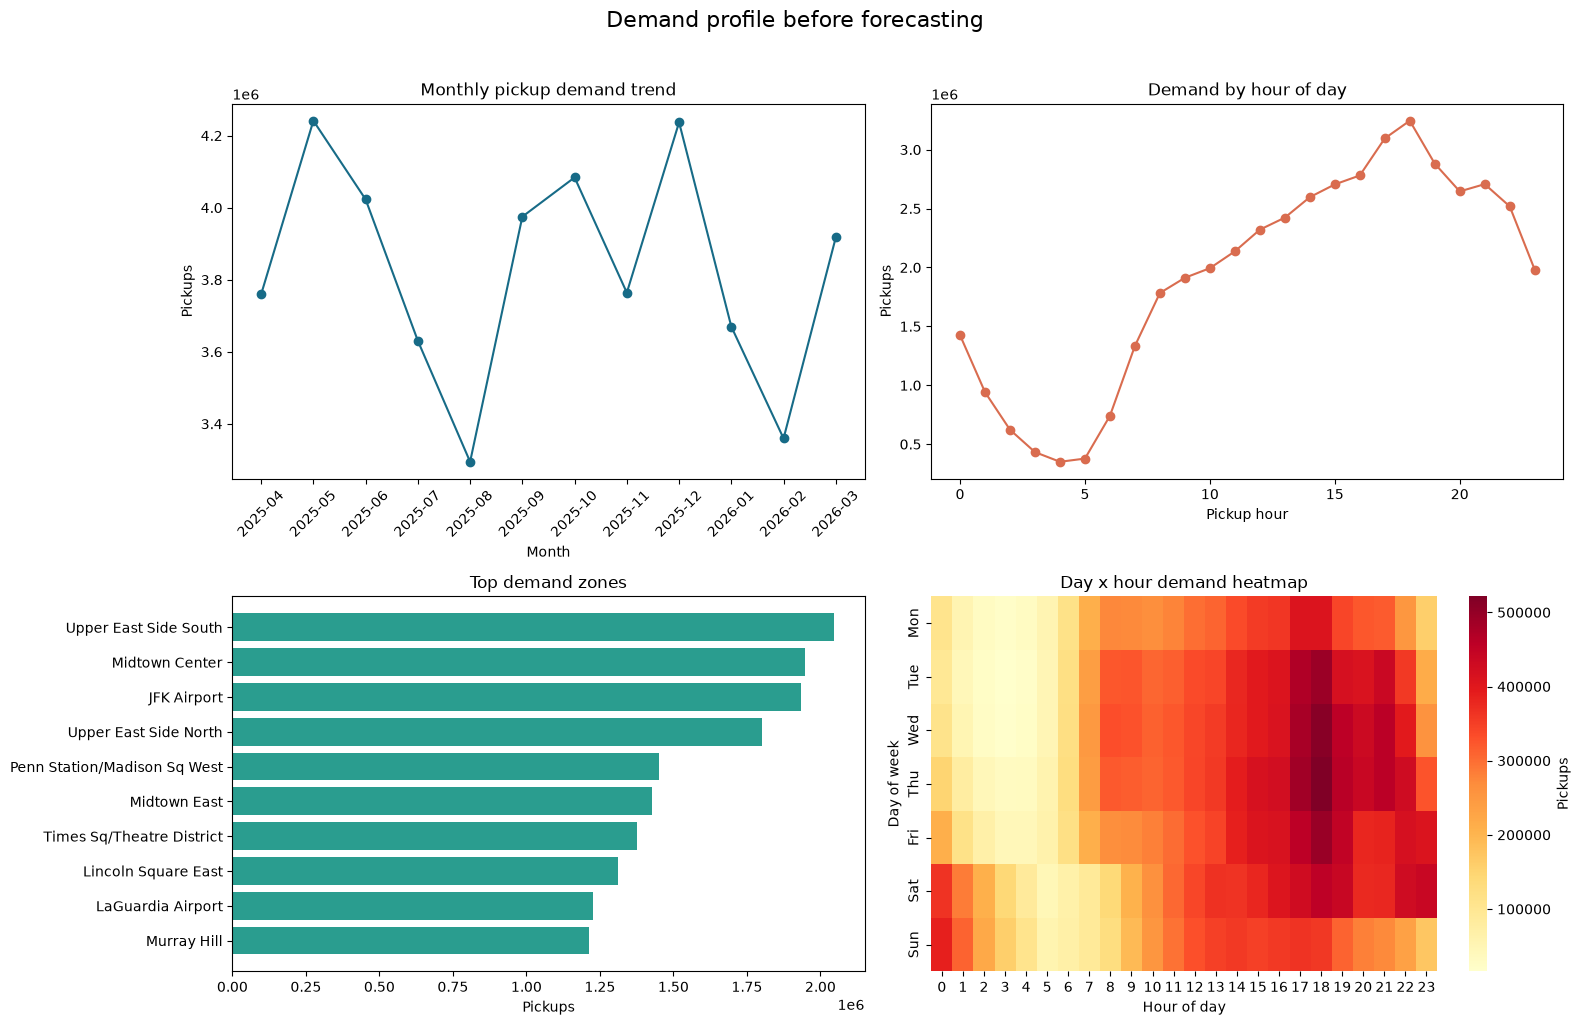

,month,pickup_count
0,2025-04,3759622
1,2025-05,4241391
2,2025-06,4023016
3,2025-07,3630420
4,2025-08,3294664
5,2025-09,3975070
6,2025-10,4083935
7,2025-11,3764008
8,2025-12,4236943
9,2026-01,3669841


,zone_id,pickup_count,borough,zone_name,service_zone
0,237,2047676,Manhattan,Upper East Side South,Yellow Zone
1,161,1946627,Manhattan,Midtown Center,Yellow Zone
2,132,1934938,Queens,JFK Airport,Airports
3,236,1802562,Manhattan,Upper East Side North,Yellow Zone
4,186,1449383,Manhattan,Penn Station/Madison Sq West,Yellow Zone
5,162,1427225,Manhattan,Midtown East,Yellow Zone
6,230,1376536,Manhattan,Times Sq/Theatre District,Yellow Zone
7,142,1312019,Manhattan,Lincoln Square East,Yellow Zone
8,138,1226964,Queens,LaGuardia Airport,Airports
9,170,1214065,Manhattan,Murray Hill,Yellow Zone


In [5]:
# Monthly trend, hourly seasonality, top zones, and day-hour heatmap.
eda_events = forecast_events.copy()
eda_events["month"] = eda_events["timestamp"].dt.to_period("M").astype(str)
eda_events["hour"] = eda_events["timestamp"].dt.hour
eda_events["dayofweek"] = eda_events["timestamp"].dt.dayofweek
eda_events["weekday"] = eda_events["timestamp"].dt.day_name().str[:3]

monthly_demand = (
    eda_events.groupby("month", as_index=False)
    .size()
    .rename(columns={"size": "pickup_count"})
)
hourly_profile = (
    eda_events.groupby("hour", as_index=False)
    .size()
    .rename(columns={"size": "pickup_count"})
)
zone_profile = (
    hourly_demand.groupby("origin_loc_id", as_index=False)["pickup_count"]
    .sum()
    .rename(columns={"origin_loc_id": "zone_id"})
    .sort_values("pickup_count", ascending=False)
    .merge(zone_metadata, on="zone_id", how="left")
)
day_hour_profile = (
    eda_events.pivot_table(
        index="weekday",
        columns="hour",
        values="timestamp",
        aggfunc="size",
        fill_value=0,
    )
    .reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(monthly_demand["month"], monthly_demand["pickup_count"], marker="o", color="#176b87")
axes[0, 0].set_title("Monthly pickup demand trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Pickups")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 1].plot(hourly_profile["hour"], hourly_profile["pickup_count"], marker="o", color="#d96c4f")
axes[0, 1].set_title("Demand by hour of day")
axes[0, 1].set_xlabel("Pickup hour")
axes[0, 1].set_ylabel("Pickups")
axes[1, 0].barh(
    zone_profile.head(10)["zone_name"].fillna(zone_profile.head(10)["zone_id"].astype(str))[::-1],
    zone_profile.head(10)["pickup_count"][::-1],
    color="#2a9d8f",
)
axes[1, 0].set_title("Top demand zones")
axes[1, 0].set_xlabel("Pickups")
heatmap = sns.heatmap(day_hour_profile, cmap="YlOrRd", ax=axes[1, 1], cbar_kws={"label": "Pickups"})
axes[1, 1].set_title("Day x hour demand heatmap")
axes[1, 1].set_xlabel("Hour of day")
axes[1, 1].set_ylabel("Day of week")
fig.suptitle("Demand profile before forecasting", fontsize=16, y=1.02)
fig.tight_layout()
eda_figure_path = FIGURE_DIR / "fleet_dispatcher_demand_eda.png"
fig.savefig(eda_figure_path, dpi=150, bbox_inches="tight")
plt.show()

display(monthly_demand)
display(zone_profile.head(TOP_N))

## 4. Create leakage-safe forecasting features

All demand-derived features are shifted before rolling. The current pickup count is never used to describe the same row, and all splits remain chronological.

In [6]:
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 72, 168]
ROLLING_HOURS = [3, 6, 12, 24, 168]

features = complete_demand.copy()
features["hour"] = features["timestamp"].dt.hour.astype("int8")
features["dayofweek"] = features["timestamp"].dt.dayofweek.astype("int8")
features["day"] = features["timestamp"].dt.day.astype("int8")
features["month"] = features["timestamp"].dt.month.astype("int8")
features["weekofyear"] = features["timestamp"].dt.isocalendar().week.astype("int8")
features["is_weekend"] = (features["dayofweek"] >= 5).astype("int8")
features["is_morning_rush"] = (
    features["dayofweek"].lt(5) & features["hour"].between(7, 10)
).astype("int8")
features["is_evening_rush"] = (
    features["dayofweek"].lt(5) & features["hour"].between(16, 20)
).astype("int8")
features["sin_hour"] = np.sin(2 * np.pi * features["hour"] / 24).astype("float32")
features["cos_hour"] = np.cos(2 * np.pi * features["hour"] / 24).astype("float32")
features["sin_dayofweek"] = np.sin(2 * np.pi * features["dayofweek"] / 7).astype("float32")
features["cos_dayofweek"] = np.cos(2 * np.pi * features["dayofweek"] / 7).astype("float32")

features = features.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
zone_groups = features.groupby("zone_id", sort=False)["pickup_count"]
for lag in LAG_HOURS:
    features[f"lag_{lag}"] = zone_groups.shift(lag)
for window in ROLLING_HOURS:
    features[f"rolling_mean_{window}"] = (
        zone_groups.shift(1).rolling(window).mean().reset_index(level=0, drop=True)
    )

feature_columns = [
    "zone_id", "hour", "dayofweek", "day", "month", "weekofyear",
    "is_weekend", "is_morning_rush", "is_evening_rush",
    "sin_hour", "cos_hour", "sin_dayofweek", "cos_dayofweek",
    *[f"lag_{lag}" for lag in LAG_HOURS],
    *[f"rolling_mean_{window}" for window in ROLLING_HOURS],
]

model_data = features.dropna(subset=feature_columns).copy()
assert model_data[feature_columns].isna().sum().sum() == 0
print(f"Feature rows available after lag history: {len(model_data):,}")
print(f"Feature count: {len(feature_columns)}")
display(model_data[["timestamp", "zone_id", "pickup_count", "lag_24", "lag_168", "rolling_mean_24"]].head())


Feature rows available after lag history: 85,920
Feature count: 27


,timestamp,zone_id,pickup_count,lag_24,lag_168,rolling_mean_24
168,2025-04-08 00:00:00,132,179,199.000,185.000,235.625
169,2025-04-08 01:00:00,132,72,95.000,293.000,234.792
170,2025-04-08 02:00:00,132,43,36.000,217.000,233.833
171,2025-04-08 03:00:00,132,12,11.000,76.000,234.125
172,2025-04-08 04:00:00,132,28,18.000,51.000,234.167


## 5. Chronological validation and seasonal baselines

Random splitting is invalid for demand forecasting. The final 30 days are reserved for testing, the previous 14 days for validation, and all earlier observations are used for training.

In [7]:
TEST_START = EXPECTED_END - pd.Timedelta(days=30)
VALIDATION_START = TEST_START - pd.Timedelta(days=14)
TRAIN_END = VALIDATION_START
EVALUATION_START = TEST_START
EVALUATION_END = TEST_START + pd.Timedelta(hours=FORECAST_HORIZON)

train_data = model_data[model_data["timestamp"] < VALIDATION_START].copy()
validation_data = model_data[
    (model_data["timestamp"] >= VALIDATION_START)
    & (model_data["timestamp"] < TEST_START)
].copy()
test_data = model_data[model_data["timestamp"] >= TEST_START].copy()

assert train_data["timestamp"].max() < validation_data["timestamp"].min()
assert validation_data["timestamp"].max() < test_data["timestamp"].min()
print("Train end:", train_data["timestamp"].max())
print("Validation:", validation_data["timestamp"].min(), "to", validation_data["timestamp"].max())
print("Test start:", test_data["timestamp"].min())

actual_eval = complete_demand[
    (complete_demand["timestamp"] >= EVALUATION_START)
    & (complete_demand["timestamp"] < EVALUATION_END)
].copy()
assert len(actual_eval) == FORECAST_HORIZON * TOP_N

history_lookup = complete_demand.set_index(["timestamp", "zone_id"])["pickup_count"]
naive_eval = actual_eval[["timestamp", "zone_id", "pickup_count"]].copy()
naive_eval["previous_hour"] = [
    history_lookup.loc[(timestamp - pd.Timedelta(hours=1), zone_id)]
    for timestamp, zone_id in zip(naive_eval["timestamp"], naive_eval["zone_id"])
]
naive_eval["seasonal_naive_168"] = [
    history_lookup.loc[(timestamp - pd.Timedelta(hours=168), zone_id)]
    for timestamp, zone_id in zip(naive_eval["timestamp"], naive_eval["zone_id"])
]

def wape(actual, predicted):
    denominator = np.abs(actual).sum()
    return np.abs(actual - predicted).sum() / denominator if denominator else np.nan

def evaluate_predictions(frame, prediction_column):
    rows = []
    for horizon_name, start_hour, end_hour in [
        ("1-24h", 1, 24), ("25-48h", 25, 48), ("49-72h", 49, 72)
    ]:
        window = frame[frame["horizon_hours"].between(start_hour, end_hour)]
        actual = window["pickup_count"].to_numpy()
        predicted = window[prediction_column].to_numpy()
        rows.append({
            "forecast": prediction_column,
            "horizon": horizon_name,
            "mae": np.mean(np.abs(actual - predicted)),
            "rmse": np.sqrt(np.mean((actual - predicted) ** 2)),
            "wape": wape(actual, predicted),
        })
    return pd.DataFrame(rows)

naive_eval["horizon_hours"] = naive_eval.groupby("zone_id").cumcount() + 1
baseline_metrics = pd.concat(
    [
        evaluate_predictions(naive_eval, "previous_hour"),
        evaluate_predictions(naive_eval, "seasonal_naive_168"),
    ],
    ignore_index=True,
)
display(baseline_metrics)


Train end: 2026-02-15 23:00:00
Validation: 2026-02-16 00:00:00 to 2026-03-01 23:00:00
Test start: 2026-03-02 00:00:00


,forecast,horizon,mae,rmse,wape
0,previous_hour,1-24h,43.308,63.639,0.243
1,previous_hour,25-48h,48.567,72.740,0.236
2,previous_hour,49-72h,45.433,66.770,0.238
3,seasonal_naive_168,1-24h,155.971,200.819,0.874
4,seasonal_naive_168,25-48h,67.700,89.837,0.329
5,seasonal_naive_168,49-72h,38.867,54.441,0.203


## 6. Train a global LightGBM forecasting modal

A single global modal learns shared hourly and weekly patterns across the selected zones while retaining `zone_id` as a spatial feature. Recursive inference generates one future hour at a time.

In [8]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

forecast_modal = LGBMRegressor(
    objective="regression",
    n_estimators=800,
    learning_rate=0.04,
    num_leaves=63,
    max_depth=-1,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
forecast_modal.fit(
    train_data[feature_columns],
    train_data["pickup_count"],
    eval_set=[(validation_data[feature_columns], validation_data["pickup_count"])],
    eval_metric="l1",
    callbacks=[early_stopping(75, verbose=False), log_evaluation(0)],
)
print(f"Best iteration: {forecast_modal.best_iteration_}")

feature_importance = (
    pd.DataFrame({"feature": feature_columns, "importance": forecast_modal.feature_importances_})
    .sort_values("importance", ascending=False)
)
display(feature_importance.head(15))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3749
[LightGBM] [Info] Number of data points in the train set: 75360, number of used features: 27
[LightGBM] [Info] Start training from score 181.093007
Best iteration: 799


,feature,importance
13,lag_1,4274
21,lag_168,4064
18,lag_24,3391
20,lag_72,2714
19,lag_48,2701
17,lag_12,2464
14,lag_2,2430
15,lag_3,2426
16,lag_6,2349
0,zone_id,2299


In [9]:
def make_future_feature_row(zone_id, timestamp, history_values):
    row = {
        "zone_id": zone_id,
        "hour": timestamp.hour,
        "dayofweek": timestamp.dayofweek,
        "day": timestamp.day,
        "month": timestamp.month,
        "weekofyear": int(timestamp.isocalendar().week),
        "is_weekend": int(timestamp.dayofweek >= 5),
        "is_morning_rush": int(timestamp.dayofweek < 5 and 7 <= timestamp.hour <= 10),
        "is_evening_rush": int(timestamp.dayofweek < 5 and 16 <= timestamp.hour <= 20),
        "sin_hour": np.sin(2 * np.pi * timestamp.hour / 24),
        "cos_hour": np.cos(2 * np.pi * timestamp.hour / 24),
        "sin_dayofweek": np.sin(2 * np.pi * timestamp.dayofweek / 7),
        "cos_dayofweek": np.cos(2 * np.pi * timestamp.dayofweek / 7),
    }
    for lag in LAG_HOURS:
        row[f"lag_{lag}"] = history_values[timestamp - pd.Timedelta(hours=lag)]
    for window in ROLLING_HOURS:
        prior_values = [
            history_values[timestamp - pd.Timedelta(hours=offset)]
            for offset in range(1, window + 1)
        ]
        row[f"rolling_mean_{window}"] = np.mean(prior_values)
    return pd.DataFrame([row], columns=feature_columns)


def recursive_forecast(forecast_origin, horizon=FORECAST_HORIZON, modal=forecast_modal):
    rows = []
    for zone_id in top_zone_ids:
        zone_history = complete_demand[
            (complete_demand["zone_id"] == zone_id)
            & (complete_demand["timestamp"] < forecast_origin)
        ]
        history_values = dict(zip(zone_history["timestamp"], zone_history["pickup_count"].astype(float)))
        for step in range(1, horizon + 1):
            timestamp = forecast_origin + pd.Timedelta(hours=step - 1)
            feature_row = make_future_feature_row(zone_id, timestamp, history_values)
            predicted_pickups = max(0.0, float(modal.predict(feature_row)[0]))
            history_values[timestamp] = predicted_pickups
            rows.append({
                "forecast_timestamp": timestamp,
                "zone_id": zone_id,
                "predicted_pickups": predicted_pickups,
                "horizon_hours": step,
            })
    return pd.DataFrame(rows)

modal_eval = recursive_forecast(TEST_START)
modal_eval = modal_eval.merge(
    actual_eval[["timestamp", "zone_id", "pickup_count"]],
    left_on=["forecast_timestamp", "zone_id"],
    right_on=["timestamp", "zone_id"],
    how="left",
).drop(columns="timestamp")
assert len(modal_eval) == FORECAST_HORIZON * TOP_N
assert modal_eval["pickup_count"].notna().all()
assert np.isfinite(modal_eval["predicted_pickups"]).all()
assert (modal_eval["predicted_pickups"] >= 0).all()
modal_metrics = evaluate_predictions(
    modal_eval.rename(columns={"forecast_timestamp": "timestamp"}),
    "predicted_pickups",
)
display(modal_metrics)


,forecast,horizon,mae,rmse,wape
0,predicted_pickups,1-24h,49.626,78.392,0.278
1,predicted_pickups,25-48h,60.161,89.867,0.292
2,predicted_pickups,49-72h,35.943,55.521,0.188


## 7. Select the best forecasting strategy by horizon

The validation period chooses between LightGBM, previous-hour, same-hour-previous-week, and weighted ensemble forecasts. The selected strategy is then locked before test evaluation to avoid test-set leakage.

In [21]:
def baseline_forecast(forecast_origin, horizon=FORECAST_HORIZON):
    complete_history = complete_demand.set_index(["timestamp", "zone_id"])["pickup_count"]
    rows = []
    for zone_id in top_zone_ids:
        zone_history = complete_demand[
            complete_demand["zone_id"] == zone_id
        ].set_index("timestamp")["pickup_count"].astype(float).to_dict()
        for step in range(1, horizon + 1):
            timestamp = forecast_origin + pd.Timedelta(hours=step - 1)
            previous_value = zone_history[timestamp - pd.Timedelta(hours=1)]
            seasonal_timestamp = timestamp - pd.Timedelta(hours=168)
            seasonal_value = (
                zone_history[seasonal_timestamp]
                if seasonal_timestamp in zone_history
                else complete_history.loc[(seasonal_timestamp, zone_id)]
            )
            rows.append({
                "forecast_timestamp": timestamp,
                "zone_id": zone_id,
                "horizon_hours": step,
                "previous_hour": previous_value,
                "seasonal_naive_168": seasonal_value,
            })
            zone_history[timestamp] = previous_value
    return pd.DataFrame(rows)


def add_strategy_candidates(forecast_origin, model, actual):
    model_forecast = recursive_forecast(
        forecast_origin,
        horizon=FORECAST_HORIZON,
        modal=model,
    ).rename(columns={"predicted_pickups": "lightgbm"})
    candidates = baseline_forecast(forecast_origin).merge(
        model_forecast[["forecast_timestamp", "zone_id", "horizon_hours", "lightgbm"]],
        on=["forecast_timestamp", "zone_id", "horizon_hours"],
        how="left",
    )
    candidates["ensemble_25_lgbm"] = (
        0.25 * candidates["lightgbm"]
        + 0.75 * candidates["previous_hour"]
    )
    candidates["ensemble_50_lgbm"] = (
        0.50 * candidates["lightgbm"]
        + 0.50 * candidates["previous_hour"]
    )
    candidates["ensemble_75_lgbm"] = (
        0.75 * candidates["lightgbm"]
        + 0.25 * candidates["previous_hour"]
    )
    return candidates.merge(
        actual[["timestamp", "zone_id", "pickup_count"]],
        left_on=["forecast_timestamp", "zone_id"],
        right_on=["timestamp", "zone_id"],
        how="left",
    ).drop(columns="timestamp")

validation_actual = complete_demand[
    (complete_demand["timestamp"] >= VALIDATION_START)
    & (complete_demand["timestamp"] < VALIDATION_START + pd.Timedelta(hours=FORECAST_HORIZON))
].copy()
validation_candidates = add_strategy_candidates(
    VALIDATION_START,
    forecast_modal,
    validation_actual,
)
strategy_columns = [
    "lightgbm",
    "previous_hour",
    "seasonal_naive_168",
    "ensemble_25_lgbm",
    "ensemble_50_lgbm",
    "ensemble_75_lgbm",
]
horizon_labels = {
    "1-24h": (1, 24),
    "25-48h": (25, 48),
    "49-72h": (49, 72),
}
selection_rows = []
for horizon_name, (start_hour, end_hour) in horizon_labels.items():
    window = validation_candidates[
        validation_candidates["horizon_hours"].between(start_hour, end_hour)
    ]
    scores = {
        strategy: wape(window["pickup_count"].to_numpy(), window[strategy].to_numpy())
        for strategy in strategy_columns
    }
    selected_strategy = min(scores, key=scores.get)
    selection_rows.append({
        "horizon": horizon_name,
        "selected_strategy": selected_strategy,
        "validation_wape": scores[selected_strategy],
        **{f"{strategy}_wape": score for strategy, score in scores.items()},
    })
strategy_selection = pd.DataFrame(selection_rows)
strategy_by_horizon = dict(
    zip(strategy_selection["horizon"], strategy_selection["selected_strategy"])
)
print("Validation-selected strategy by horizon:")
display(strategy_selection[["horizon", "selected_strategy", "validation_wape"]])

Validation-selected strategy by horizon:


,horizon,selected_strategy,validation_wape
0,1-24h,ensemble_75_lgbm,0.337
1,25-48h,ensemble_75_lgbm,0.208
2,49-72h,lightgbm,0.134


## 7. Train and evaluate the production forecasting workflow

The production model is refit on the complete historical feature window after model selection. It creates a recursive 72-hour forecast and ranks zones over 6, 12, 24, and 72-hour operating windows.

In [22]:
production_modal = LGBMRegressor(
    objective="regression",
    n_estimators=max(100, int(forecast_modal.best_iteration_ or 800)),
    learning_rate=0.04,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
production_modal.fit(
    model_data[feature_columns],
    model_data["pickup_count"],
    callbacks=[log_evaluation(0)],
)

production_model_forecast = recursive_forecast(
    EXPECTED_END,
    horizon=FORECAST_HORIZON,
    modal=production_modal,
).rename(columns={"predicted_pickups": "lightgbm"})
production_candidates = baseline_forecast(EXPECTED_END).merge(
    production_model_forecast[["forecast_timestamp", "zone_id", "horizon_hours", "lightgbm"]],
    on=["forecast_timestamp", "zone_id", "horizon_hours"],
    how="left",
)
production_candidates["ensemble_25_lgbm"] = (
    0.25 * production_candidates["lightgbm"]
    + 0.75 * production_candidates["previous_hour"]
)
production_candidates["ensemble_50_lgbm"] = (
    0.50 * production_candidates["lightgbm"]
    + 0.50 * production_candidates["previous_hour"]
)
production_candidates["ensemble_75_lgbm"] = (
    0.75 * production_candidates["lightgbm"]
    + 0.25 * production_candidates["previous_hour"]
)
production_candidates["selected_strategy"] = production_candidates["horizon_hours"].map(
    lambda hour: strategy_by_horizon[
        next(
            label
            for label, (start_hour, end_hour) in horizon_labels.items()
            if start_hour <= hour <= end_hour
        )
    ]
)
production_candidates["predicted_pickups"] = production_candidates.apply(
    lambda row: row[row["selected_strategy"]],
    axis=1,
)
future_forecast = production_candidates[
    ["forecast_timestamp", "zone_id", "horizon_hours", "predicted_pickups", "selected_strategy"]
].merge(zone_metadata, on="zone_id", how="left")
assert len(future_forecast) == FORECAST_HORIZON * TOP_N
assert future_forecast["forecast_timestamp"].nunique() == FORECAST_HORIZON

horizon_windows = {
    "next_6h": 6,
    "next_12h": 12,
    "next_24h": 24,
    "next_72h": 72,
}
dispatcher_rows = []
for window_name, window_hours in horizon_windows.items():
    ranking = (
        future_forecast[future_forecast["horizon_hours"] <= window_hours]
        .groupby("zone_id", as_index=False)["predicted_pickups"]
        .sum()
        .rename(columns={"predicted_pickups": "predicted_pickups_total"})
        .merge(zone_metadata, on="zone_id", how="left")
        .sort_values("predicted_pickups_total", ascending=False)
    )
    ranking["rank"] = np.arange(1, len(ranking) + 1)
    ranking["forecast_window"] = window_name
    ranking["demand_level"] = pd.qcut(
        ranking["predicted_pickups_total"].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"],
    )
    dispatcher_rows.append(ranking)

dispatcher_recommendations = pd.concat(dispatcher_rows, ignore_index=True)
print("Validation-selected strategy by horizon:")
display(strategy_selection[["horizon", "selected_strategy", "validation_wape"]])
print("Top 6-hour dispatcher priorities:")
display(
    dispatcher_recommendations[
        dispatcher_recommendations["forecast_window"] == "next_6h"
    ].head(10)
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003669 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3757
[LightGBM] [Info] Number of data points in the train set: 85920, number of used features: 27
[LightGBM] [Info] Start training from score 179.494844
Validation-selected strategy by horizon:


,horizon,selected_strategy,validation_wape
0,1-24h,ensemble_75_lgbm,0.337
1,25-48h,ensemble_75_lgbm,0.208
2,49-72h,lightgbm,0.134


Top 6-hour dispatcher priorities:


,zone_id,predicted_pickups_total,borough,zone_name,service_zone,rank,forecast_window,demand_level
0,132,830.685,Queens,JFK Airport,Airports,1,next_6h,High
1,230,528.430,Manhattan,Times Sq/Theatre District,Yellow Zone,2,next_6h,High
2,138,359.414,Queens,LaGuardia Airport,Airports,3,next_6h,High
3,161,325.033,Manhattan,Midtown Center,Yellow Zone,4,next_6h,Medium
4,186,277.386,Manhattan,Penn Station/Madison Sq West,Yellow Zone,5,next_6h,Medium
5,162,219.215,Manhattan,Midtown East,Yellow Zone,6,next_6h,Medium
6,170,213.451,Manhattan,Murray Hill,Yellow Zone,7,next_6h,Low
7,142,197.561,Manhattan,Lincoln Square East,Yellow Zone,8,next_6h,Low
8,237,194.102,Manhattan,Upper East Side South,Yellow Zone,9,next_6h,Low
9,236,113.680,Manhattan,Upper East Side North,Yellow Zone,10,next_6h,Low


## 8. Evaluate, visualize, and save results

,forecast,horizon,mae,rmse,wape
0,previous_hour,1-24h,43.308,63.639,0.243
1,previous_hour,25-48h,48.567,72.740,0.236
2,previous_hour,49-72h,45.433,66.770,0.238
3,seasonal_naive_168,1-24h,155.971,200.819,0.874
4,seasonal_naive_168,25-48h,67.700,89.837,0.329
5,seasonal_naive_168,49-72h,38.867,54.441,0.203
6,predicted_pickups,1-24h,49.626,78.392,0.278
7,predicted_pickups,25-48h,60.161,89.867,0.292
8,predicted_pickups,49-72h,35.943,55.521,0.188


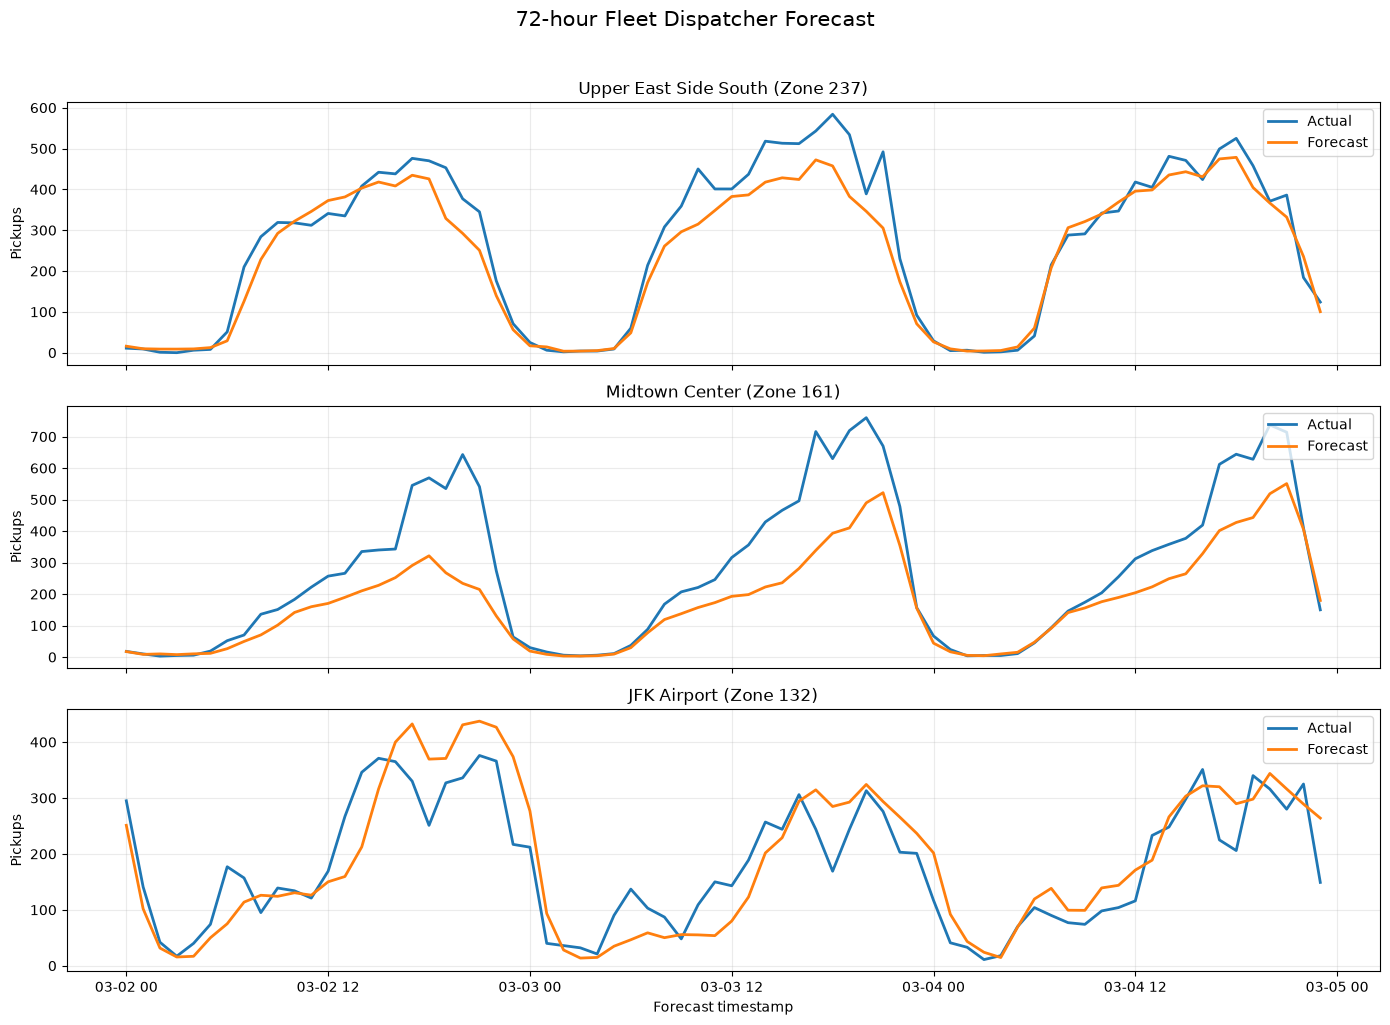

Saved forecast, dispatcher, metrics, and forecast plot outputs.


In [11]:
all_metrics = pd.concat(
    [baseline_metrics, modal_metrics],
    ignore_index=True,
)
display(all_metrics)

plot_zone_ids = top_zone_ids[:3]
plot_data = modal_eval[modal_eval["zone_id"].isin(plot_zone_ids)].copy()
plot_data = plot_data.merge(zone_metadata[["zone_id", "zone_name"]], on="zone_id", how="left")

fig, axes = plt.subplots(len(plot_zone_ids), 1, figsize=(14, 10), sharex=True)
axes = np.atleast_1d(axes)
for axis, zone_id in zip(axes, plot_zone_ids):
    zone_frame = plot_data[plot_data["zone_id"] == zone_id].sort_values("forecast_timestamp")
    axis.plot(zone_frame["forecast_timestamp"], zone_frame["pickup_count"], label="Actual", linewidth=2)
    axis.plot(zone_frame["forecast_timestamp"], zone_frame["predicted_pickups"], label="Forecast", linewidth=2)
    axis.set_title(f"{zone_frame['zone_name'].iloc[0]} (Zone {zone_id})")
    axis.set_ylabel("Pickups")
    axis.legend(loc="upper right")
    axis.grid(alpha=0.25)
axes[-1].set_xlabel("Forecast timestamp")
fig.suptitle("72-hour Fleet Dispatcher Forecast", y=1.02, fontsize=15)
fig.tight_layout()
forecast_figure_path = FIGURE_DIR / "fleet_dispatcher_72_hour_forecast.png"
fig.savefig(forecast_figure_path, dpi=140, bbox_inches="tight")
plt.show()

forecast_output_path = REPORT_DIR / "fleet_dispatcher_72_hour_forecast.csv"
dispatcher_output_path = REPORT_DIR / "fleet_dispatcher_zone_recommendations.csv"
metrics_output_path = REPORT_DIR / "fleet_dispatcher_forecast_metrics.csv"

future_forecast.to_csv(forecast_output_path, index=False)
dispatcher_recommendations.to_csv(dispatcher_output_path, index=False)
all_metrics.to_csv(metrics_output_path, index=False)

assert all(path.exists() for path in [
    forecast_output_path,
    dispatcher_output_path,
    metrics_output_path,
    forecast_figure_path,
])
print("Saved forecast, dispatcher, metrics, and forecast plot outputs.")

## 9. Evaluate the LightGBM model

A single LightGBM model is trained with early stopping on the validation period. The test period remains untouched until this evaluation step.

In [23]:
test_candidates = add_strategy_candidates(
    TEST_START,
    forecast_modal,
    actual_eval,
)
test_candidates["selected_strategy"] = test_candidates["horizon_hours"].map(
    lambda hour: strategy_by_horizon[
        next(
            label
            for label, (start_hour, end_hour) in horizon_labels.items()
            if start_hour <= hour <= end_hour
        )
    ]
)
test_candidates["predicted_pickups"] = test_candidates.apply(
    lambda row: row[row["selected_strategy"]],
    axis=1,
)
selected_test_scored = test_candidates.copy()
selected_test_metrics = evaluate_predictions(
    selected_test_scored,
    "predicted_pickups",
).assign(forecast="horizon_selected_strategy")

all_metrics = pd.concat(
    [baseline_metrics, modal_metrics, selected_test_metrics],
    ignore_index=True,
)
all_metrics.to_csv(
    REPORT_DIR / "fleet_dispatcher_test_metrics.csv",
    index=False,
)
print("Test performance of the validation-selected strategy:")
display(selected_test_metrics)

Test performance of the validation-selected strategy:


,forecast,horizon,mae,rmse,wape
0,horizon_selected_strategy,1-24h,67.769,98.469,0.380
1,horizon_selected_strategy,25-48h,85.123,122.287,0.413
2,horizon_selected_strategy,49-72h,35.943,55.521,0.188


## 25-27. Model diagnostics

Diagnostics translate aggregate scores into operational evidence: how errors change with forecast horizon, which zones are harder to predict, which features drive the model, and whether actual demand tracks the forecast.

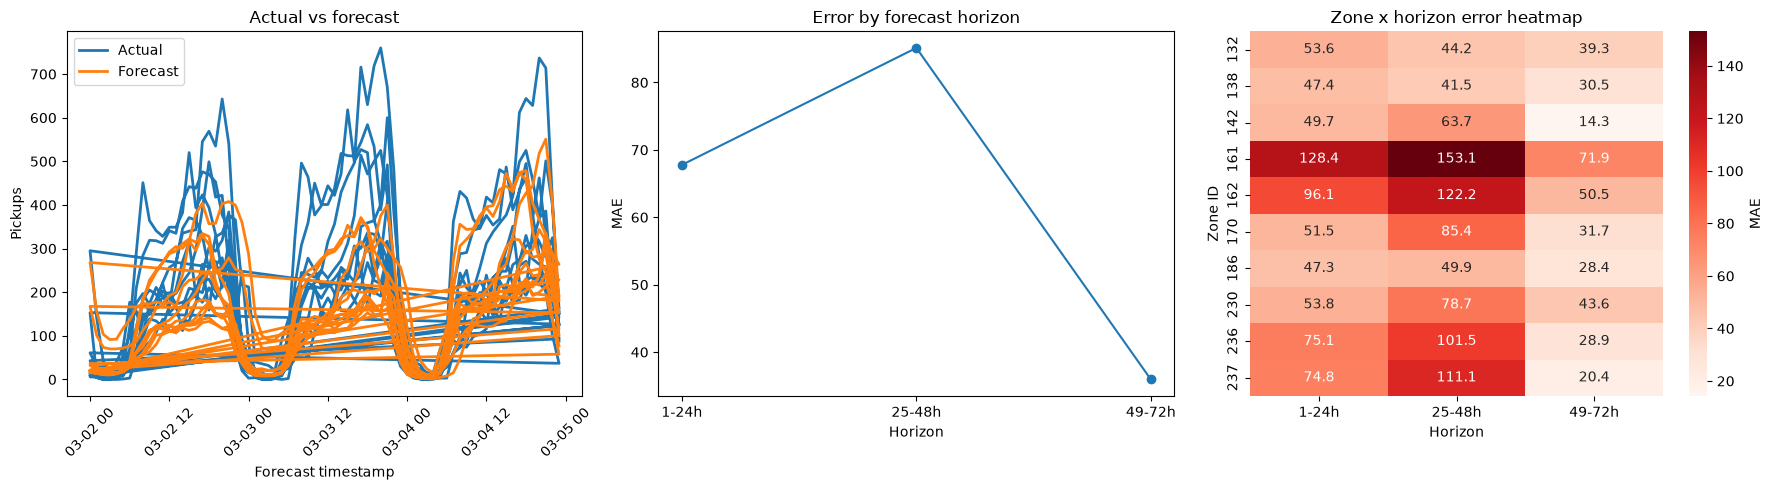

,horizon_group,mae,rmse,mean_bias
0,1-24h,67.769,98.469,-48.731
1,25-48h,85.123,122.287,-68.093
2,49-72h,35.943,55.521,-17.579


,zone_id,mae,bias,actual_pickups,borough,zone_name,service_zone
3,161,117.803,-114.931,19552,Manhattan,Midtown Center,Yellow Zone
4,162,89.603,-86.164,14539,Manhattan,Midtown East,Yellow Zone
9,237,68.785,-61.115,19267,Manhattan,Upper East Side South,Yellow Zone
8,236,68.481,-56.038,18318,Manhattan,Upper East Side North,Yellow Zone
7,230,58.714,-52.487,11309,Manhattan,Times Sq/Theatre District,Yellow Zone
5,170,56.177,-53.651,10644,Manhattan,Murray Hill,Yellow Zone
0,132,45.678,30.225,12931,Queens,JFK Airport,Airports
2,142,42.556,-31.547,10596,Manhattan,Lincoln Square East,Yellow Zone
6,186,41.861,-32.920,11042,Manhattan,Penn Station/Madison Sq West,Yellow Zone
1,138,39.795,10.617,9897,Queens,LaGuardia Airport,Airports


,feature,importance
13,lag_1,4274
21,lag_168,4064
18,lag_24,3391
20,lag_72,2714
19,lag_48,2701
17,lag_12,2464
14,lag_2,2430
15,lag_3,2426
16,lag_6,2349
0,zone_id,2299


In [24]:
diagnostic_frame = selected_test_scored.copy()
diagnostic_frame["absolute_error"] = (
    diagnostic_frame["pickup_count"] - diagnostic_frame["predicted_pickups"]
).abs()
diagnostic_frame["signed_error"] = (
    diagnostic_frame["predicted_pickups"] - diagnostic_frame["pickup_count"]
)
diagnostic_frame["horizon_group"] = pd.cut(
    diagnostic_frame["horizon_hours"],
    bins=[0, 24, 48, 72],
    labels=["1-24h", "25-48h", "49-72h"],
)
zone_metrics = (
    diagnostic_frame.groupby("zone_id", as_index=False)
    .agg(
        mae=("absolute_error", "mean"),
        bias=("signed_error", "mean"),
        actual_pickups=("pickup_count", "sum"),
    )
    .merge(zone_metadata, on="zone_id", how="left")
    .sort_values("mae", ascending=False)
)
horizon_metrics = (
    diagnostic_frame.groupby("horizon_group", observed=False, as_index=False)
    .agg(
        mae=("absolute_error", "mean"),
        rmse=("signed_error", lambda values: np.sqrt(np.mean(values ** 2))),
        mean_bias=("signed_error", "mean"),
    )
)
error_heatmap = diagnostic_frame.pivot_table(
    index="zone_id",
    columns="horizon_group",
    values="absolute_error",
    aggfunc="mean",
).reindex(columns=["1-24h", "25-48h", "49-72h"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(
    diagnostic_frame["forecast_timestamp"],
    diagnostic_frame["pickup_count"],
    label="Actual",
    linewidth=2,
)
axes[0].plot(
    diagnostic_frame["forecast_timestamp"],
    diagnostic_frame["predicted_pickups"],
    label="Forecast",
    linewidth=2,
)
axes[0].set_title("Actual vs forecast")
axes[0].set_xlabel("Forecast timestamp")
axes[0].set_ylabel("Pickups")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)
axes[1].plot(horizon_metrics["horizon_group"].astype(str), horizon_metrics["mae"], marker="o")
axes[1].set_title("Error by forecast horizon")
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("MAE")
sns.heatmap(error_heatmap, annot=True, fmt=".1f", cmap="Reds", ax=axes[2], cbar_kws={"label": "MAE"})
axes[2].set_title("Zone x horizon error heatmap")
axes[2].set_xlabel("Horizon")
axes[2].set_ylabel("Zone ID")
fig.tight_layout()
diagnostics_figure_path = FIGURE_DIR / "fleet_dispatcher_model_diagnostics.png"
fig.savefig(diagnostics_figure_path, dpi=150, bbox_inches="tight")
plt.show()

display(horizon_metrics)
display(zone_metrics)
display(feature_importance.head(15))

## 11. Use the selected production forecast

The production forecast and dispatcher recommendations already use the strategy selected from validation.

In [25]:
selected_production_modal = production_modal
selected_future_forecast = future_forecast.copy()
selected_dispatcher_recommendations = dispatcher_recommendations.copy()
print("Using the validation-selected production forecast.")
display(
    selected_dispatcher_recommendations[
        selected_dispatcher_recommendations["forecast_window"] == "next_6h"
    ].head(10)
)

Using the validation-selected production forecast.


,zone_id,predicted_pickups_total,borough,zone_name,service_zone,rank,forecast_window,demand_level
0,132,830.685,Queens,JFK Airport,Airports,1,next_6h,High
1,230,528.430,Manhattan,Times Sq/Theatre District,Yellow Zone,2,next_6h,High
2,138,359.414,Queens,LaGuardia Airport,Airports,3,next_6h,High
3,161,325.033,Manhattan,Midtown Center,Yellow Zone,4,next_6h,Medium
4,186,277.386,Manhattan,Penn Station/Madison Sq West,Yellow Zone,5,next_6h,Medium
5,162,219.215,Manhattan,Midtown East,Yellow Zone,6,next_6h,Medium
6,170,213.451,Manhattan,Murray Hill,Yellow Zone,7,next_6h,Low
7,142,197.561,Manhattan,Lincoln Square East,Yellow Zone,8,next_6h,Low
8,237,194.102,Manhattan,Upper East Side South,Yellow Zone,9,next_6h,Low
9,236,113.680,Manhattan,Upper East Side North,Yellow Zone,10,next_6h,Low


## 11. Save the forecast, metrics, model, and metadata

The production LightGBM model is saved as a standard `.pkl` artifact with metadata for reproducibility.

In [26]:
from datetime import datetime, timezone
import json
import pickle

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
modal_artifact_path = MODEL_DIR / "fleet_dispatcher_lgbm.pkl"
metadata_artifact_path = MODEL_DIR / "fleet_dispatcher_metadata.json"
strategy_output_path = REPORT_DIR / "fleet_dispatcher_strategy_selection.csv"

with modal_artifact_path.open("wb") as model_file:
    pickle.dump(
        selected_production_modal,
        model_file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )
strategy_selection.to_csv(strategy_output_path, index=False)

metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source": str(SOURCE_PATH),
    "forecast_granularity": "hourly",
    "forecast_horizon_hours": FORECAST_HORIZON,
    "zone_ids": [int(zone_id) for zone_id in top_zone_ids],
    "feature_columns": feature_columns,
    "model": "LightGBM regression with validation-selected horizon strategies",
    "model_parameters": best_config,
    "strategy_by_horizon": strategy_by_horizon,
    "test_metrics": selected_test_metrics.to_dict(orient="records"),
}
with metadata_artifact_path.open("w", encoding="utf-8") as metadata_file:
    json.dump(metadata, metadata_file, indent=2, default=str)

assert modal_artifact_path.exists()
assert metadata_artifact_path.exists()
assert strategy_output_path.exists()
print(f"Saved model: {modal_artifact_path}")
print(f"Saved metadata: {metadata_artifact_path}")
print(f"Saved strategy selection: {strategy_output_path}")

Saved model: c:\Users\kATANA GF66\My_Main\datathon\Datathon-2026-team-DataCraft\models\fleet_dispatcher_lgbm.pkl
Saved metadata: c:\Users\kATANA GF66\My_Main\datathon\Datathon-2026-team-DataCraft\models\fleet_dispatcher_metadata.json
Saved strategy selection: c:\Users\kATANA GF66\My_Main\datathon\Datathon-2026-team-DataCraft\reports\fleet_dispatcher_strategy_selection.csv


## 15. Save improvement diagnostics

In [27]:
for output_path in [
    forecast_output_path,
    dispatcher_output_path,
    metrics_output_path,
    strategy_output_path,
    modal_artifact_path,
    metadata_artifact_path,
]:
    assert output_path.exists(), f"Missing output: {output_path}"

assert len(selected_future_forecast) == TOP_N * FORECAST_HORIZON
assert selected_future_forecast["forecast_timestamp"].nunique() == FORECAST_HORIZON
print("Fleet Dispatcher core outputs validated and saved.")

Fleet Dispatcher core outputs validated and saved.


## 29-30. Final artifacts and business conclusion

The final section creates the handoff package for the dashboard or dispatcher: forecasts, rankings, model metrics, diagnostics, plots, the trained pickle model, and metadata describing how the artifact was produced.

In [28]:
diagnostic_output_paths = {
    "horizon_metrics": REPORT_DIR / "fleet_dispatcher_horizon_metrics.csv",
    "zone_metrics": REPORT_DIR / "fleet_dispatcher_zone_metrics.csv",
    "eda_summary": REPORT_DIR / "fleet_dispatcher_eda_monthly.csv",
}
horizon_metrics.to_csv(diagnostic_output_paths["horizon_metrics"], index=False)
zone_metrics.to_csv(diagnostic_output_paths["zone_metrics"], index=False)
monthly_demand.to_csv(diagnostic_output_paths["eda_summary"], index=False)

selected_future_forecast.to_csv(forecast_output_path, index=False)
selected_dispatcher_recommendations.to_csv(dispatcher_output_path, index=False)
all_metrics.to_csv(metrics_output_path, index=False)

required_artifacts = [
    forecast_output_path,
    dispatcher_output_path,
    metrics_output_path,
    forecast_figure_path,
    eda_figure_path,
    diagnostics_figure_path,
    modal_artifact_path,
    metadata_artifact_path,
    *diagnostic_output_paths.values(),
]
assert all(path.exists() for path in required_artifacts)

best_test_wape = float(selected_test_metrics["wape"].mean())
print("Fleet Dispatcher pipeline complete")
print(f"Forecast horizon: {FORECAST_HORIZON} hours")
print(f"Demand zones: {TOP_N}")
print(f"Selected model: {best_candidate_name}")
print(f"Mean test WAPE: {best_test_wape:.1%}")
print("Use the saved recommendations to rank zones for the next 6, 12, 24, or 72 hours.")

Fleet Dispatcher pipeline complete
Forecast horizon: 72 hours
Demand zones: 10
Selected model: lightgbm_baseline
Mean test WAPE: 32.7%
Use the saved recommendations to rank zones for the next 6, 12, 24, or 72 hours.


### Conclusion

The workflow compares simple baselines with LightGBM and selects the best strategy separately for each forecast horizon using validation WAPE. The final dispatcher output ranks zones by predicted pickup demand for the next 6, 12, 24, and 72 hours.

The forecast is a planning aid, not a guarantee of realized trips. Weather, events, road closures, pricing changes, and fleet availability are external drivers that can be added in future versions.